Install and Import Packages

In [4]:
!pip install gseapy matplotlib seaborn pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

Load the Limma Result and Define Gene Lists

In [5]:
# Load the enriched result (with gene symbols)
res = pd.read_csv("/workspaces/Malaria-host-response-systems/data/processed/limma_voom_symptomatic_vs_asymptomatic_with_symbols.csv")

# Filter for significant genes (per-contrast BH adj.P.Val < 0.15)
sig = res[(res['adj.P.Val'] < 0.15) & res['Symbol'].notna()]

# Up in symptomatic (positive logFC), down in asymptomatic
up_genes = sig[sig['logFC'] > 0]['Symbol'].tolist()
# Down in symptomatic (negative logFC), i.e., up in asymptomatic
down_genes = sig[sig['logFC'] < 0]['Symbol'].tolist()

print(f"Total significant genes: {len(sig)}")
print(f"Up in symptomatic: {len(up_genes)}")
print(f"Down in symptomatic: {len(down_genes)}")

Total significant genes: 280
Up in symptomatic: 200
Down in symptomatic: 80


Run Enrichr for GO, KEGG, and Reactome

In [6]:
# Define gene set libraries
gene_sets = {
    'GO_Biological_Process_2023': 'GO_BP',
    'KEGG_2021_Human': 'KEGG',
    'Reactome_2022': 'Reactome'
}

# Enrichment for up-regulated genes
enr_up = {}
for lib, label in gene_sets.items():
    enr = gp.enrichr(gene_list=up_genes,
                     gene_sets=lib,
                     organism='human',
                     outdir=None,
                     cutoff=0.1)
    enr_up[label] = enr.results

# Enrichment for down-regulated genes
enr_down = {}
for lib, label in gene_sets.items():
    enr = gp.enrichr(gene_list=down_genes,
                     gene_sets=lib,
                     organism='human',
                     outdir=None,
                     cutoff=0.1)
    enr_down[label] = enr.results

print("Enrichment completed.")

Enrichment completed.


Inspect Top Terms for Up‑Regulated Genes (Symptomatic)

In [7]:
top_go_up = enr_up['GO_BP'].head(10)
print("Top GO BP terms up in symptomatic:")
print(top_go_up[['Term', 'Overlap', 'Adjusted P-value', 'Combined Score']])

Top GO BP terms up in symptomatic:
                                                Term Overlap  \
0  Mitotic Sister Chromatid Segregation (GO:0000070)  15/111   
1  Positive Regulation Of Cell Cycle Process (GO:...  14/118   
2                   Mitotic Cytokinesis (GO:0000281)    9/59   
3  Regulation Of Attachment Of Spindle Microtubul...     5/9   
4          Mitotic Spindle Organization (GO:0007052)   10/85   
5  Positive Regulation Of DNA-directed DNA Polyme...    5/12   
6  Regulation Of DNA-directed DNA Polymerase Acti...    5/12   
7             Regulation Of Cytokinesis (GO:0032465)    9/80   
8    Cytoskeleton-Dependent Cytokinesis (GO:0061640)    9/81   
9  Microtubule Cytoskeleton Organization Involved...    8/59   

   Adjusted P-value  Combined Score  
0      4.882052e-10      477.530153  
1      9.383326e-09      357.015528  
2      3.210637e-06      350.001975  
3      3.682594e-06     2318.700367  
4      3.682594e-06      251.326027  
5      1.437356e-05     1193.263

Inspect Top Terms for Down‑Regulated Genes (Asymptomatic)

In [8]:
top_go_down = enr_down['GO_BP'].head(10)
print("Top GO BP terms down in symptomatic (up in asymptomatic):")
print(top_go_down[['Term', 'Overlap', 'Adjusted P-value', 'Combined Score']])

Top GO BP terms down in symptomatic (up in asymptomatic):
                                                Term Overlap  \
0  Positive Regulation Of Release Of Cytochrome C...    3/25   
1  Negative Regulation Of Cell Differentiation (G...   6/207   
2       Neuron Projection Morphogenesis (GO:0048812)   5/146   
3         Peptidyl-Lysine Deacetylation (GO:0034983)     2/7   
4  Regulation Of Release Of Cytochrome C From Mit...    3/41   
5       Neuron Projection Fasciculation (GO:0106030)    2/10   
6  Midbrain Dopaminergic Neuron Differentiation (...    2/10   
7  Positive Regulation Of Apoptotic Process (GO:0...   6/270   
8  Negative Regulation Of Transcription By RNA Po...  10/763   
9                  Axonal Fasciculation (GO:0007413)    2/12   

   Adjusted P-value  Combined Score  
0          0.062965      314.504473  
1          0.062965       68.511804  
2          0.062965       75.868954  
3          0.062965      819.473651  
4          0.071731      151.611895  
5        

Save Results to CSV

In [10]:
for label, df in enr_up.items():
    df.to_csv(f"/workspaces/Malaria-host-response-systems/data/processed/enrichr_{label}_up_symptomatic.csv", index=False)
for label, df in enr_down.items():
    df.to_csv(f"/workspaces/Malaria-host-response-systems/data/processed/enrichr_{label}_down_symptomatic.csv", index=False)

print("Saved enrichment results.")

Saved enrichment results.


Visualize Top Enriched Terms

/tmp/ipykernel_46326/3874616417.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, y='Term', x='Combined Score', palette='viridis')


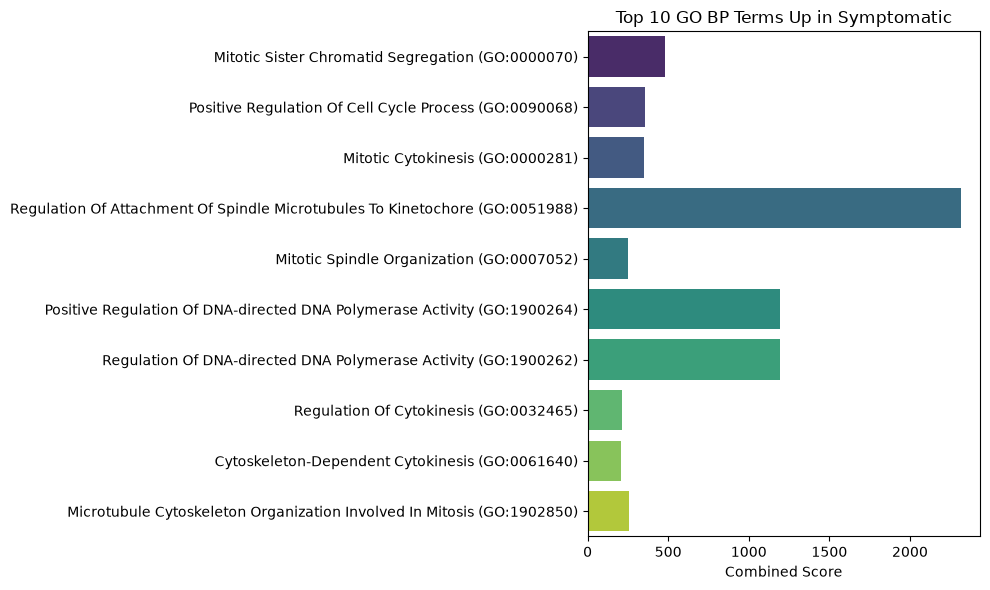

/tmp/ipykernel_46326/3874616417.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, y='Term', x='Combined Score', palette='viridis')


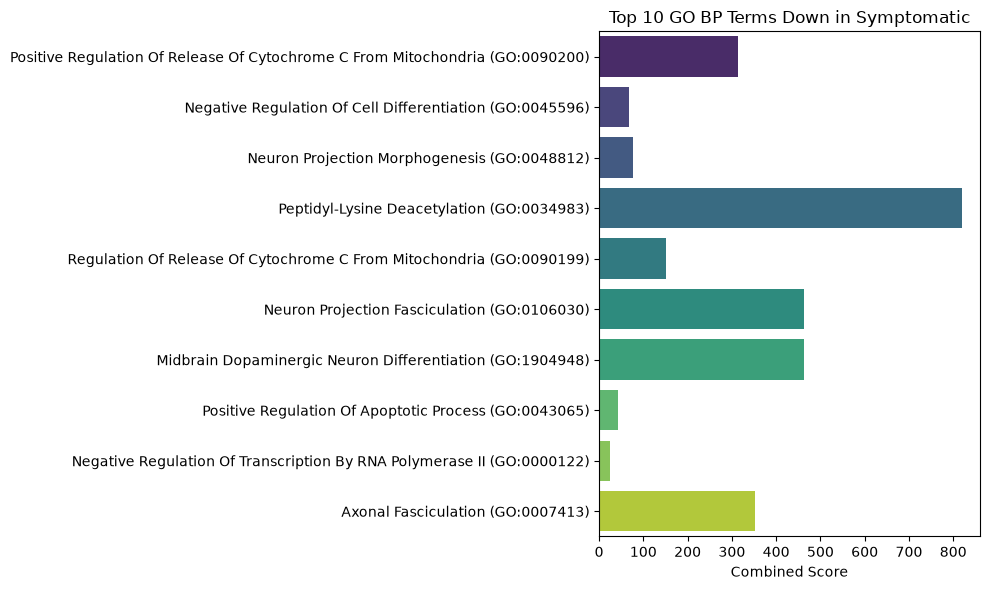

In [12]:
def plot_top_terms(df, title, n=10):
    df_sorted = df.sort_values('Adjusted P-value').head(n)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_sorted, y='Term', x='Combined Score', palette='viridis')
    plt.title(title)
    plt.xlabel('Combined Score')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(f'/workspaces/Malaria-host-response-systems/results/figures/{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_top_terms(enr_up['GO_BP'], 'Top 10 GO BP Terms Up in Symptomatic')
plot_top_terms(enr_down['GO_BP'], 'Top 10 GO BP Terms Down in Symptomatic')